# Analiza szeregów czasowych (M.S.) - laboratorium 10 (3 XII 2025)
# TEMATY: Modelowanie danych z wykorzystaniem szeregów GARCH 
#         Testowanie hipotez zagnieżdżonych

## 1. Praca z danymi realnymi: analiza i modelowanie log-zwrotów z Bitcoin
###    link do danych:  https://fred.stlouisfed.org/series/CBBTCUSD

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, norm, chi2
from arch import arch_model   # pip install arch

In [12]:
daneD = pd.read_csv("CBBTCUSDd.csv", decimal=";")

daneD.head()


,observation_date,CBBTCUSD
0,2023-07-09,30171.10
1,2023-07-10,30427.52
2,2023-07-11,30636.22
3,2023-07-12,30379.01
4,2023-07-13,31471.53


In [13]:
try:
    daneD["Data"] = pd.to_datetime(daneD["Data"])
except Exception:
    pass

In [14]:
daneD.columns = ["Data", "BTC"]

Xtd = daneD["BTC"].values

### b) Analiza wstępna dziennych log-zwrotów BTC 

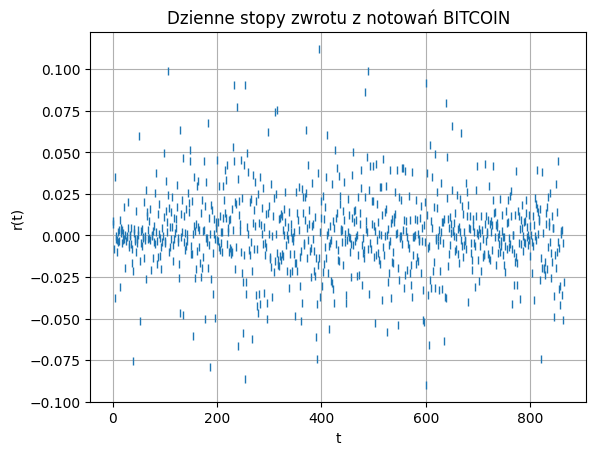

In [16]:
# ensure prices are numeric (they are currently strings), then compute log-returns
Xtd = Xtd.astype(float)                     # convert array of string prices to floats
Rtd = np.diff(np.log(Xtd))   # odpowiednik diff(log(Xtd))

plt.figure()
plt.plot(Rtd, linestyle="none", marker="|")
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title("Dzienne stopy zwrotu z notowań BITCOIN")
plt.grid(True)
plt.show()

In [17]:
stat, p_value = shapiro(Rtd)
print("Shapiro–Wilk dla Rtd: stat =", stat, ", p-value =", p_value)

Shapiro–Wilk dla Rtd: stat = 0.9617177011398156 , p-value = 2.824391346548496e-14


### c) dopasowanie modelu GARCH(1,1) – QMLE


In [18]:
# domyślnie arch_model estymuje przez (Q)MLE z rozkładem normalnym
am = arch_model(Rtd, vol="GARCH", p=1, q=1, dist="normal", mean="constant")
modelg11 = am.fit(update_freq=10, disp="off")


c:\REPO\studia\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005961. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [19]:
# estymatory QMLE
print("Estymatory QMLE (parametry modelu GARCH(1,1)):")
print(modelg11.params)

Estymatory QMLE (parametry modelu GARCH(1,1)):
mu          0.001223
omega       0.000046
alpha[1]    0.074969
beta[1]     0.849278
Name: params, dtype: float64


In [20]:
# diagnostyka: odpowiednik summary(modelg11)
print(modelg11.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                2007.78
Distribution:                  Normal   AIC:                          -4007.55
Method:            Maximum Likelihood   BIC:                          -3988.50
                                        No. Observations:                  866
Date:                Wed, Dec 03 2025   Df Residuals:                      865
Time:                        09:30:01   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.2232e-03  7.671e-04      1.595      0.111 

In [21]:
epst_ = modelg11.resid   # reszty

stat_eps, p_eps = shapiro(epst_)
print("Shapiro–Wilk dla reszt: stat =", stat_eps, ", p-value =", p_eps)

Shapiro–Wilk dla reszt: stat = 0.9617177011398156 , p-value = 2.824391346548496e-14


### d) kalkulacja Value-at-Risk

In [22]:
alfa_ = 0.05
q_ = norm.ppf(alfa_)     # kwantyl N(0,1)
K = 1_000_000

In [23]:
sigmat_ = modelg11.conditional_volatility  # odpowiednik sigma.t w R

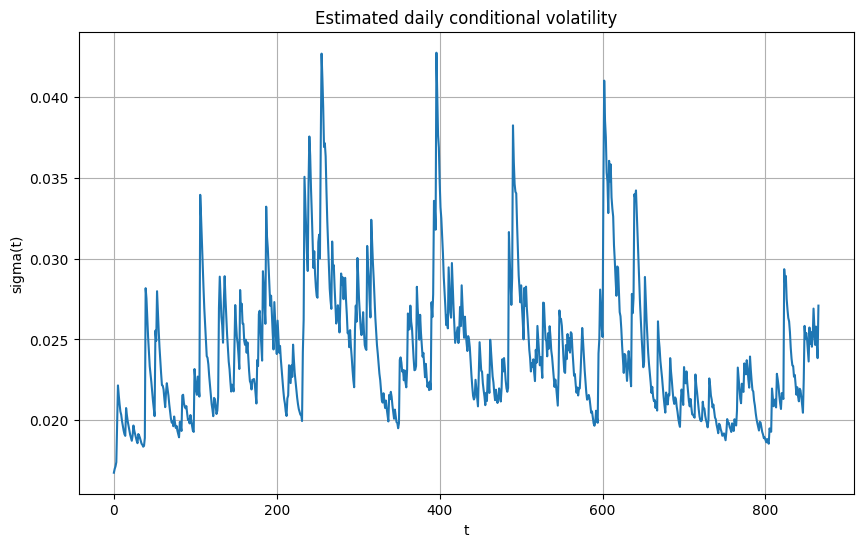

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(sigmat_)
plt.xlabel("t")
plt.ylabel("sigma(t)")
plt.title("Estimated daily conditional volatility")
plt.grid(True)
plt.show()

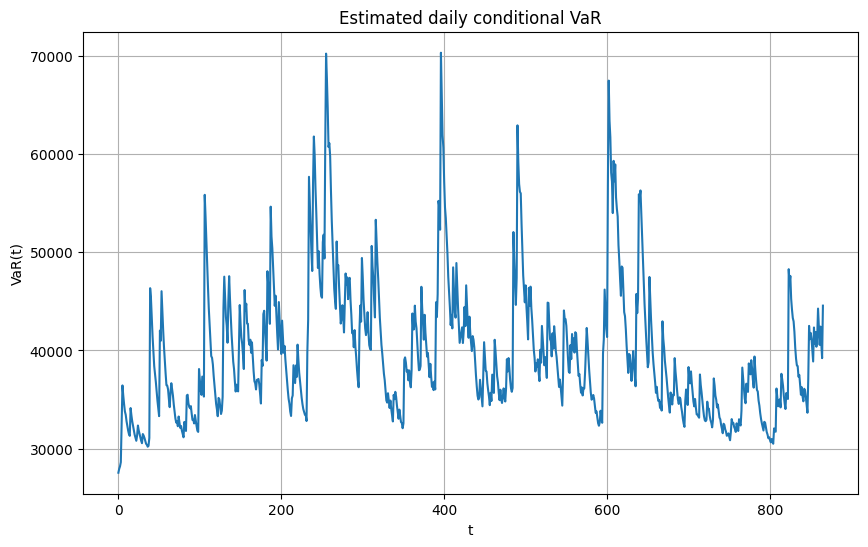

In [27]:
# modyfikacja: dzienny VaR (przy założeniu E[r_t]=0)
VaR_t = -K * q_ * sigmat_

plt.figure(figsize=(10, 6))
plt.plot(VaR_t)
plt.xlabel("t")
plt.ylabel("VaR(t)")
plt.title("Estimated daily conditional VaR")
plt.grid(True)
plt.show()

### 3. Testowanie dla hipotez zagnieżdżonych

In [28]:
# symulacja trajektorii ARCH(2):
# model: sigma_t^2 = omega + alpha1 * eps_{t-1}^2 + alpha2 * eps_{t-2}^2

np.random.seed(123)

omega = 1e-6
alpha1 = 0.4
alpha2 = 0.2

n = 300
n_start = 200
T = n + n_start

eps = np.zeros(T)
sigma2 = np.zeros(T)
z = np.random.normal(size=T)

In [29]:
# start: mała dodatnia wariancja
sigma2[0] = omega / (1 - alpha1 - alpha2)
eps[0] = np.sqrt(sigma2[0]) * z[0]
sigma2[1] = omega + alpha1 * eps[0]**2
eps[1] = np.sqrt(sigma2[1]) * z[1]

for t in range(2, T):
    sigma2[t] = omega + alpha1 * eps[t-1]**2 + alpha2 * eps[t-2]**2
    eps[t] = np.sqrt(sigma2[t]) * z[t]

rt_ = eps[n_start:]   # odpowiednik rt_$garch (n = 300 obserwacji)

In [30]:
# oszacowanie 2 konkurencyjnych modeli: mniejszy (Restricted), większy (Unrestricted)

# Restricted: ARCH(1)  ~ garch(1,0) w R
am1 = arch_model(rt_, vol="ARCH", p=1, dist="normal", mean="zero")
mg1 = am1.fit(update_freq=10, disp="off")

# Unrestricted: ARCH(2) ~ garch(2,0) w R
am2 = arch_model(rt_, vol="ARCH", p=2, dist="normal", mean="zero")
mg2 = am2.fit(update_freq=10, disp="off")

c:\REPO\studia\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.096e-06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
c:\REPO\studia\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.096e-06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1000 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [31]:
print("Parametry Restricted (ARCH(1)):")
print(mg1.params)
print("Log-likelihood Restricted:", mg1.loglikelihood)

Parametry Restricted (ARCH(1)):
omega       0.000001
alpha[1]    0.416750
Name: params, dtype: float64
Log-likelihood Restricted: 1552.2109436430103


In [32]:
print("Parametry Unrestricted (ARCH(2)):")
print(mg2.params)
print("Log-likelihood Unrestricted:", mg2.loglikelihood)

Parametry Unrestricted (ARCH(2)):
omega       0.000001
alpha[1]    0.250000
alpha[2]    0.250000
Name: params, dtype: float64
Log-likelihood Unrestricted: 1559.1720167588069


In [33]:
lnLR = mg1.loglikelihood   # log L_R
lnLU = mg2.loglikelihood   # log L_U

In [34]:
print("lnLR, lnLU =", lnLR, lnLU)

lnLR, lnLU = 1552.2109436430103 1559.1720167588069


In [35]:
# test ilorazu wiarygodności dla hipotez zagnieżdżonych
testLR = -2 * (lnLR - lnLU)
print("Statystyka testu LR:", testLR)

Statystyka testu LR: 13.92214623159316


In [36]:
# asymptotyczna wartość krytyczna (tu zgodnie ze skryptem df = 2)
c_ = chi2.ppf(0.95, df=2)
print("Wartość krytyczna chi^2_{0.95,2}:", c_)

Wartość krytyczna chi^2_{0.95,2}: 5.991464547107979


In [ ]:
import numpy as np

def boundary_matrices(complex):
    """
    Wyznacza wszystkie macierze operatorów brzegu dla danego kompleksu symplicjalnego.
    
    Parametry:
    complex (list of lists): Lista list, gdzie complex[n] to lista sympleksów stopnia n.
                            Każdy sympleks to krotka (tuple) wierzchołków (indeksów).
    
    Zwraca:
    list of np.ndarray: Lista macierzy operatorów brzegu, gdzie macierz[i] odpowiada ∂_{i+1} : C_{i+1} -> C_i.
    """
    if not complex:
        return []
    
    matrices = []
    for n in range(1, len(complex)):
        if not complex[n] or not complex[n-1]:
            matrices.append(np.zeros((len(complex[n-1]), len(complex[n]))))
            continue
        
        # Mapowanie sympleksów do indeksów
        simplex_to_index = {simplex: idx for idx, simplex in enumerate(complex[n])}
        face_to_index = {face: idx for idx, face in enumerate(complex[n-1])}
        
        # Inicjalizacja macierzy
        matrix = np.zeros((len(complex[n-1]), len(complex[n])))
        
        for j, simplex in enumerate(complex[n]):
            # Obliczanie brzegu sympleksu
            boundary = []
            for i in range(len(simplex)):
                face = tuple(sorted(simplex[:i] + simplex[i+1:]))
                if face in face_to_index:
                    sign = (-1) ** i
                    boundary.append((face_to_index[face], sign))
            
            for face_idx, sign in boundary:
                matrix[face_idx, j] = sign
        
        matrices.append(matrix)
    
    return matrices